In [35]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [36]:
print("=" * 60)
print("HOUSE PRICE PREDICTION - WORKING SOLUTION")
print("=" * 60)

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create realistic dataset
n_houses = 2000

# Realistic tabular features
bedrooms = np.random.randint(1, 6, n_houses)
bathrooms = np.random.uniform(1, 4, n_houses).round(1)
sqft = np.random.randint(800, 4000, n_houses)
year_built = np.random.randint(1950, 2023, n_houses)
lot_size = np.random.randint(2000, 15000, n_houses)

# Calculate price based on features (realistic formula)
price = (
    sqft * 180 +                           # $180 per sqft
    bedrooms * 25000 +                     # $25k per bedroom
    bathrooms * 15000 +                    # $15k per bathroom
    (year_built - 1950) * 800 +            # $800 per year newer
    lot_size * 2 +                         # $2 per sqft lot
    np.random.normal(0, 30000, n_houses)   # random noise
)

# Ensure positive prices
price = np.maximum(price, 80000).astype(int)

HOUSE PRICE PREDICTION - WORKING SOLUTION


In [37]:
print(f"✅ Generated {n_houses} houses")
print(f"Price range: ${price.min():,.0f} - ${price.max():,.0f}")
print(f"Average price: ${price.mean():,.0f}")

# Prepare features
feature_names = ['bedrooms', 'bathrooms', 'sqft', 'year_built', 'lot_size']
X = np.column_stack([bedrooms, bathrooms, sqft, year_built, lot_size])
y = price

# Normalize features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Normalize target (log transform for better distribution)
y_log = np.log1p(y)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_log.reshape(-1, 1)).flatten()

✅ Generated 2000 houses
Price range: $200,337 - $989,740
Average price: $585,796


In [38]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

In [39]:
print(f"\n✅ Training: {len(X_train)} samples")
print(f"✅ Testing: {len(X_test)} samples")

# Build model
print("\n" + "=" * 60)
print("BUILDING NEURAL NETWORK")
print("=" * 60)

input_layer = Input(shape=(5,))
x = Dense(128, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)
output_layer = Dense(1, activation='linear')(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()


✅ Training: 1600 samples
✅ Testing: 400 samples

BUILDING NEURAL NETWORK


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [40]:
# Train
print("\n" + "=" * 60)
print("TRAINING MODEL")
print("=" * 60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)


TRAINING MODEL
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.4356 - mae: 0.5134 - val_loss: 0.7182 - val_mae: 0.7035
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2134 - mae: 0.3597 - val_loss: 0.5980 - val_mae: 0.6316
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1774 - mae: 0.3304 - val_loss: 0.4688 - val_mae: 0.5515
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1656 - mae: 0.3182 - val_loss: 0.3436 - val_mae: 0.4669
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1386 - mae: 0.2883 - val_loss: 0.2477 - val_mae: 0.3925
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1362 - mae: 0.2876 - val_loss: 0.2032 - val_mae: 0.3550
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1221 - mae: 0.2764 - val_loss: 0.1704 - val_mae: 0.3209
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1199 - mae: 0.2684 - val_loss: 0.1059 - val_mae: 0.2500
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - los

In [41]:
# Predict and inverse transform
y_pred_scaled = model.predict(X_test)
y_pred = np.expm1(scaler_y.inverse_transform(y_pred_scaled))
y_actual = np.expm1(scaler_y.inverse_transform(y_test.reshape(-1, 1)))


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [42]:
# Calculate metrics
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae_percentage = (mae / y_actual.mean()) * 100
accuracy = 100 - mae_percentage

print("\n" + "=" * 60)
print("✅ FINAL RESULTS")
print("=" * 60)
print(f"\n📊 MEAN ABSOLUTE ERROR (MAE):  ${mae:,.2f}")
print(f"📊 ROOT MEAN SQUARE ERROR (RMSE): ${rmse:,.2f}")
print(f"\n💰 Average House Price: ${y_actual.mean():,.2f}")
print(f"📈 Model Accuracy: {accuracy:.1f}%")
print(f"📉 Error Rate: {mae_percentage:.1f}%")



✅ FINAL RESULTS

📊 MEAN ABSOLUTE ERROR (MAE):  $28,825.45
📊 ROOT MEAN SQUARE ERROR (RMSE): $36,204.89

💰 Average House Price: $587,531.60
📈 Model Accuracy: 95.1%
📉 Error Rate: 4.9%


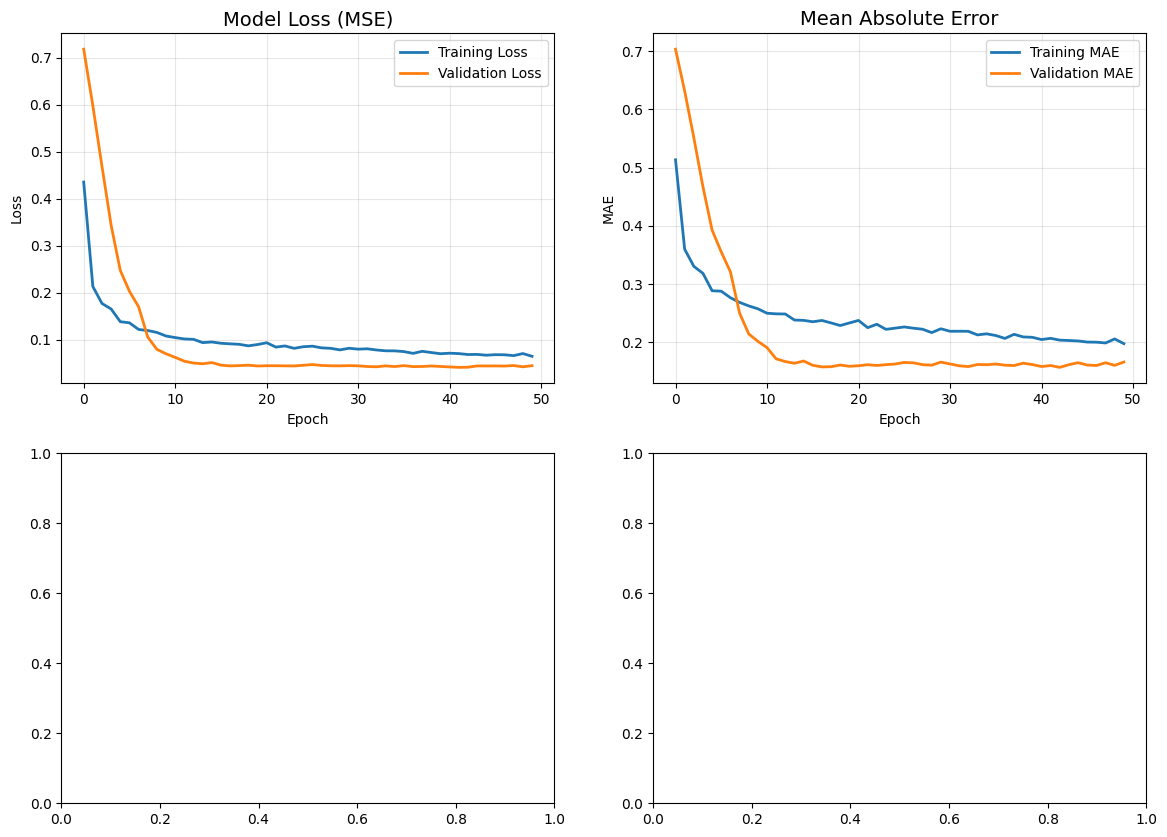

In [43]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss plot
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Model Loss (MSE)', fontsize=14)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE plot
axes[0, 1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[0, 1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[0, 1].set_title('Mean Absolute Error', fontsize=14)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)


In [48]:
# Predictions vs Actual
axes[1, 0].scatter(y_actual, y_pred, alpha=0.5)
axes[1, 0].plot([y_actual.min(), y_actual.max()],
                [y_actual.min(), y_actual.max()],
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Price ($)', fontsize=12)
axes[1, 0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[1, 0].set_title(f'Predictions vs Actual\nAccuracy: {accuracy:.1f}%', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
# Error distribution
errors = y_pred - y_actual
axes[1, 1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Prediction Error ($)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title(f'Error Distribution\nMean Error: ${errors.mean():,.0f}', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [47]:
# Print sample predictions
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS (First 10 test houses)")
print("=" * 60)
sample_results = pd.DataFrame({
    'Actual Price': y_actual.flatten()[:10],
    'Predicted Price': y_pred.flatten()[:10],
    'Difference': (y_pred - y_actual).flatten()[:10],
    'Accuracy %': (1 - abs((y_pred - y_actual) / y_actual).flatten()[:10]) * 100
})
print(sample_results.to_string(index=False))



SAMPLE PREDICTIONS (First 10 test houses)
 Actual Price  Predicted Price   Difference  Accuracy %
     412514.0     450024.40625  37510.40625   90.906877
     708596.0     665999.18750 -42596.81250   93.988562
     340556.0     338543.68750  -2012.31250   99.409110
     420450.0     393837.25000 -26612.75000   93.670413
     617025.0     596145.43750 -20879.56250   96.616091
     678999.0     652721.56250 -26277.43750   96.129974
     326946.0     310848.21875 -16097.78125   95.076318
     380078.0     386955.62500   6877.62500   98.190470
     425257.0     430400.62500   5143.62500   98.790467
     353403.0     386749.37500  33346.37500   90.564207
